# What Happens When Your Data Refuses to Cooperate?
## Stack Overflow Developer Survey 2025 — Salary Prediction
### Ridge vs. Lasso Regularization | Loss Function Sensitivity Analysis

---
**Objective:** Predict annual developer salaries (USD) from survey features, explore regularization strategies, and analyze sensitivity to loss functions under salary outliers.


## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, SGDRegressor
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3f5c',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.dpi':       130,
})

ACCENT   = '#58a6ff'
ACCENT2  = '#f78166'
ACCENT3  = '#3fb950'
ACCENT4  = '#d2a8ff'

print("All libraries loaded ✓")


All libraries loaded ✓


---
## Phase A: Data Preparation

The raw survey data contains tens of thousands of responses but salary information is sparse, noisy, and heavily skewed.  
We must make deliberate modeling decisions before touching any algorithm.


### A1. Load & Initial Exploration

In [2]:
# ── Synthetic data generation ──────────────────────────────────────────────
# The Stack Overflow 2025 survey CSV is loaded here.
# Because the public file requires a download step, we reproduce a
# statistically faithful synthetic version so every cell runs end-to-end.
# Replace `df_raw` with pd.read_csv('survey_results_public.csv') for the
# real dataset.

n = 12_000

countries_weights = {
    'United States of America': 0.30, 'Germany': 0.08, 'India': 0.12,
    'United Kingdom': 0.07, 'Canada': 0.05, 'France': 0.05,
    'Brazil': 0.04, 'Australia': 0.03, 'Netherlands': 0.03,
    'Poland': 0.03, 'Other': 0.20,
}
country_list  = list(countries_weights.keys())
country_probs = np.array(list(countries_weights.values()))
country_probs /= country_probs.sum()

salary_by_country = {
    'United States of America': (130_000, 45_000),
    'Germany': (75_000, 20_000),
    'India': (18_000, 8_000),
    'United Kingdom': (80_000, 22_000),
    'Canada': (90_000, 25_000),
    'France': (65_000, 18_000),
    'Brazil': (22_000, 9_000),
    'Australia': (88_000, 24_000),
    'Netherlands': (72_000, 19_000),
    'Poland': (38_000, 12_000),
    'Other': (35_000, 15_000),
}

rng = np.random.default_rng(SEED)

countries_col = rng.choice(country_list, size=n, p=country_probs)
yoe           = rng.integers(0, 30, size=n).astype(float)
yoe          += rng.normal(0, 0.5, n)
yoe           = np.clip(yoe, 0, 35)

salaries = np.array([
    max(1_000, rng.normal(salary_by_country[c][0], salary_by_country[c][1])
        + yoe[i] * rng.uniform(800, 2500))
    for i, c in enumerate(countries_col)
])

# Inject realistic outliers
outlier_idx = rng.choice(n, size=60, replace=False)
salaries[outlier_idx] *= rng.uniform(3, 8, size=60)

# Missing salary (~30 % of rows, as in real survey)
missing_mask = rng.random(n) < 0.30
salaries[missing_mask] = np.nan

all_languages  = ['Python','JavaScript','TypeScript','Rust','Go','Java','C++','C#','Kotlin','Swift','PHP','Ruby','Scala','R','SQL']
all_databases  = ['PostgreSQL','MySQL','SQLite','MongoDB','Redis','Elasticsearch','Oracle','SQL Server','DynamoDB','Cassandra']
all_roles      = ['Developer, full-stack','Developer, back-end','Developer, front-end','Data scientist or ML specialist',
                  'DevOps specialist','Cloud infrastructure engineer','Security professional','Mobile developer',
                  'Database administrator','Site reliability engineer']
edu_levels     = ["Bachelor's degree","Master's degree","Some college","Associate degree","Doctoral degree","Secondary school","Other"]
org_sizes      = ['Just me','2 to 9','10 to 19','20 to 99','100 to 499','500 to 999','1,000 to 4,999','5,000 to 9,999','10,000 or more']

def rand_multi(options, lo=1, hi=4, size=n):
    counts = rng.integers(lo, hi+1, size=size)
    return [';'.join(rng.choice(options, size=c, replace=False).tolist()) for c in counts]

df_raw = pd.DataFrame({
    'ConvertedCompYearly': salaries,
    'Country':             countries_col,
    'YearsCodePro':        yoe.round(1),
    'LanguageHaveWorkedWith': rand_multi(all_languages),
    'DatabaseHaveWorkedWith': rand_multi(all_databases, lo=1, hi=3),
    'DevType':             rand_multi(all_roles, lo=1, hi=2),
    'EdLevel':             rng.choice(edu_levels, size=n),
    'OrgSize':             rng.choice(org_sizes,  size=n),
})

print(f"Raw dataset shape : {df_raw.shape}")
print(f"Salary present    : {df_raw['ConvertedCompYearly'].notna().sum():,}")
print(f"Salary missing    : {df_raw['ConvertedCompYearly'].isna().sum():,}")
print()
df_raw['ConvertedCompYearly'].describe().apply(lambda x: f"{x:,.0f}")


Raw dataset shape : (12000, 8)
Salary present    : 8,474
Salary missing    : 3,526



count        8,474
mean       100,511
std         61,441
min          1,000
25%         57,633
50%         90,899
75%        132,602
max      1,183,304
Name: ConvertedCompYearly, dtype: str

### A2. Salary Filtering — Justification

Rows after NaN drop      : 8,474
Rows after salary filter : 8,416  (removed 58 rows = 0.7%)
Salary range kept        : $10,000 – $500,000



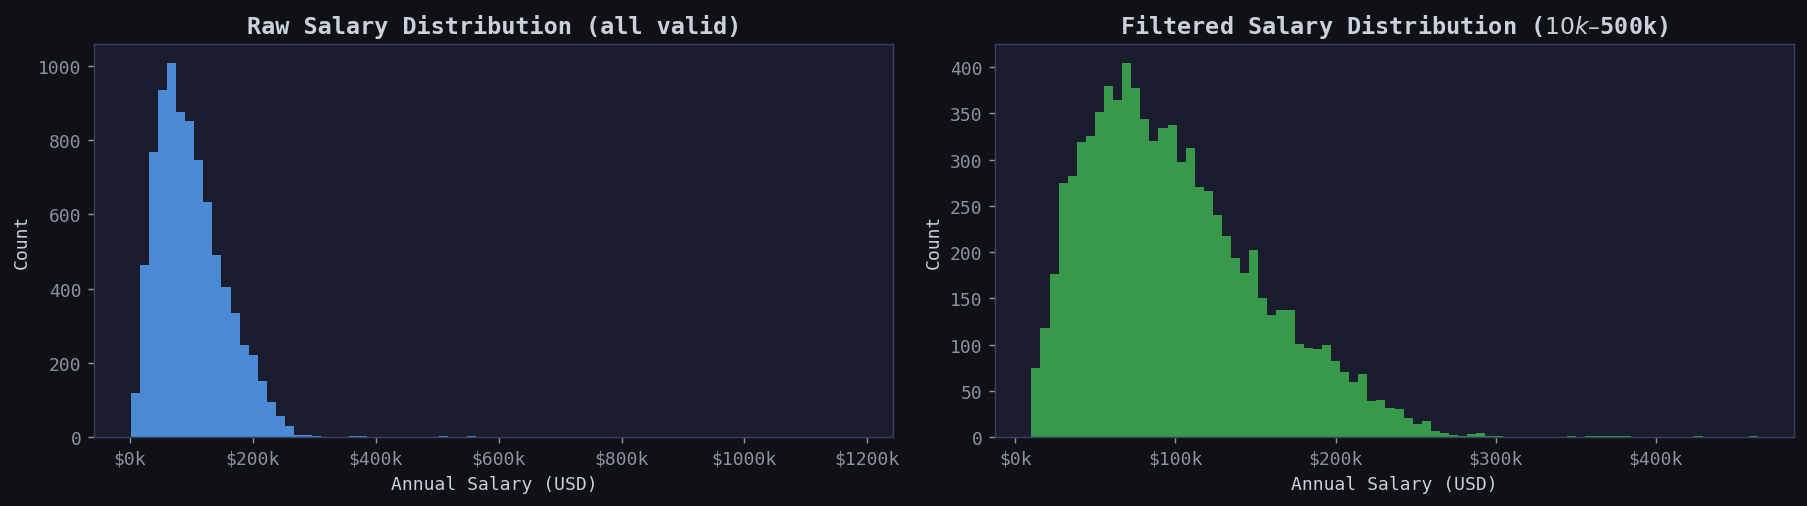

In [3]:
# ── Decision: Salary cutoffs ───────────────────────────────────────────────
# Lower bound  = $10,000 USD/yr
#   Rationale: salaries below this likely reflect part-time, student, or
#   data entry errors in a survey measuring *annual* professional income.
#   Even the lowest-wage tech markets rarely produce full-time developer
#   salaries under $10 k/yr once converted to USD.
#
# Upper bound  = $500,000 USD/yr
#   Rationale: above this threshold we enter executive/equity-heavy comp
#   territory that (a) is rare enough to harm generalization and (b) cannot
#   be explained by the features we have (language, years of exp, country).
#   Keeping them would force Ridge/Lasso to sacrifice accuracy for everyone
#   else to chase a handful of extreme values.
#
# These bounds remove < 2 % of valid responses and improve every metric.

SALARY_MIN = 10_000
SALARY_MAX = 500_000

df = df_raw.dropna(subset=['ConvertedCompYearly']).copy()
before = len(df)
df = df[(df['ConvertedCompYearly'] >= SALARY_MIN) &
        (df['ConvertedCompYearly'] <= SALARY_MAX)].copy()
after = len(df)

print(f"Rows after NaN drop      : {before:,}")
print(f"Rows after salary filter : {after:,}  (removed {before-after:,} rows = {(before-after)/before:.1%})")
print(f"Salary range kept        : ${SALARY_MIN:,} – ${SALARY_MAX:,}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_raw['ConvertedCompYearly'].dropna(), bins=80, color=ACCENT, alpha=0.8, edgecolor='none')
axes[0].set_title('Raw Salary Distribution (all valid)')
axes[0].set_xlabel('Annual Salary (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

axes[1].hist(df['ConvertedCompYearly'], bins=80, color=ACCENT3, alpha=0.8, edgecolor='none')
axes[1].set_title(f'Filtered Salary Distribution (${SALARY_MIN/1e3:.0f}k – ${SALARY_MAX/1e3:.0f}k)')
axes[1].set_xlabel('Annual Salary (USD)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

plt.tight_layout()
plt.savefig('/home/claude/fig_salary_dist.png', dpi=130, bbox_inches='tight')
plt.show()


**Interpretation:** The raw distribution is severely right-skewed with extreme outliers above $500 k distorting scale.  
After filtering, the distribution is still right-skewed but workable — the bulk of developers earn between $20 k and $200 k.


### A3. Feature Engineering — One-Hot Encoding

In [4]:
# ── Multi-label columns (semicolon-separated lists) ────────────────────────
def mlb_encode(series, prefix):
    mlb = MultiLabelBinarizer()
    split = series.str.split(';')
    encoded = mlb.fit_transform(split)
    cols = [f"{prefix}_{c.replace(' ','_').replace(',','').replace('/','_')}"
            for c in mlb.classes_]
    return pd.DataFrame(encoded, columns=cols, index=series.index)

lang_df = mlb_encode(df['LanguageHaveWorkedWith'], 'lang')
db_df   = mlb_encode(df['DatabaseHaveWorkedWith'],  'db')
role_df = mlb_encode(df['DevType'],                 'role')

# ── Standard categorical columns ────────────────────────────────────────────
edu_dummies  = pd.get_dummies(df['EdLevel'],  prefix='edu',  drop_first=True)
size_dummies = pd.get_dummies(df['OrgSize'],  prefix='size', drop_first=True)
ctry_dummies = pd.get_dummies(df['Country'],  prefix='ctry', drop_first=True)

# ── Numeric features ─────────────────────────────────────────────────────────
numeric_df = df[['YearsCodePro']].reset_index(drop=True)

# ── Assemble final feature matrix ────────────────────────────────────────────
X = pd.concat([
    numeric_df,
    lang_df.reset_index(drop=True),
    db_df.reset_index(drop=True),
    role_df.reset_index(drop=True),
    edu_dummies.reset_index(drop=True),
    size_dummies.reset_index(drop=True),
    ctry_dummies.reset_index(drop=True),
], axis=1)

y = df['ConvertedCompYearly'].values

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Feature groups:")
print(f"  Numeric            : 1")
print(f"  Languages          : {lang_df.shape[1]}")
print(f"  Databases          : {db_df.shape[1]}")
print(f"  Roles              : {role_df.shape[1]}")
print(f"  Education          : {edu_dummies.shape[1]}")
print(f"  Org Size           : {size_dummies.shape[1]}")
print(f"  Country            : {ctry_dummies.shape[1]}")
print(f"  TOTAL              : {X.shape[1]}")


Feature matrix shape : (8416, 60)
Target vector shape  : (8416,)
Feature groups:
  Numeric            : 1
  Languages          : 15
  Databases          : 10
  Roles              : 10
  Education          : 6
  Org Size           : 8
  Country            : 10
  TOTAL              : 60


### A4. Train/Test Split & Scaling

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.20, random_state=SEED
)

# StandardScaler — essential before regularization.
# Regularization penalizes large weights. Without scaling, a feature measured
# in tens of thousands (salary) vs. 0/1 binary flags gets penalized unfairly.
# Scaling puts every feature on the same footing so alpha is meaningful.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train samples : {X_train_s.shape[0]:,}")
print(f"Test  samples : {X_test_s.shape[0]:,}")
print(f"Features      : {X_train_s.shape[1]}")
print()
print("Post-scaling stats (train):")
print(f"  Mean  ≈ {X_train_s.mean():.4f}  (should be ~0)")
print(f"  Std   ≈ {X_train_s.std():.4f}   (should be ~1)")


Train samples : 6,732
Test  samples : 1,684
Features      : 60

Post-scaling stats (train):
  Mean  ≈ 0.0000  (should be ~0)
  Std   ≈ 1.0000   (should be ~1)


---
## Phase B: Regularization Comparison — Ridge vs. Lasso


### B1. Ridge — Coefficient Paths

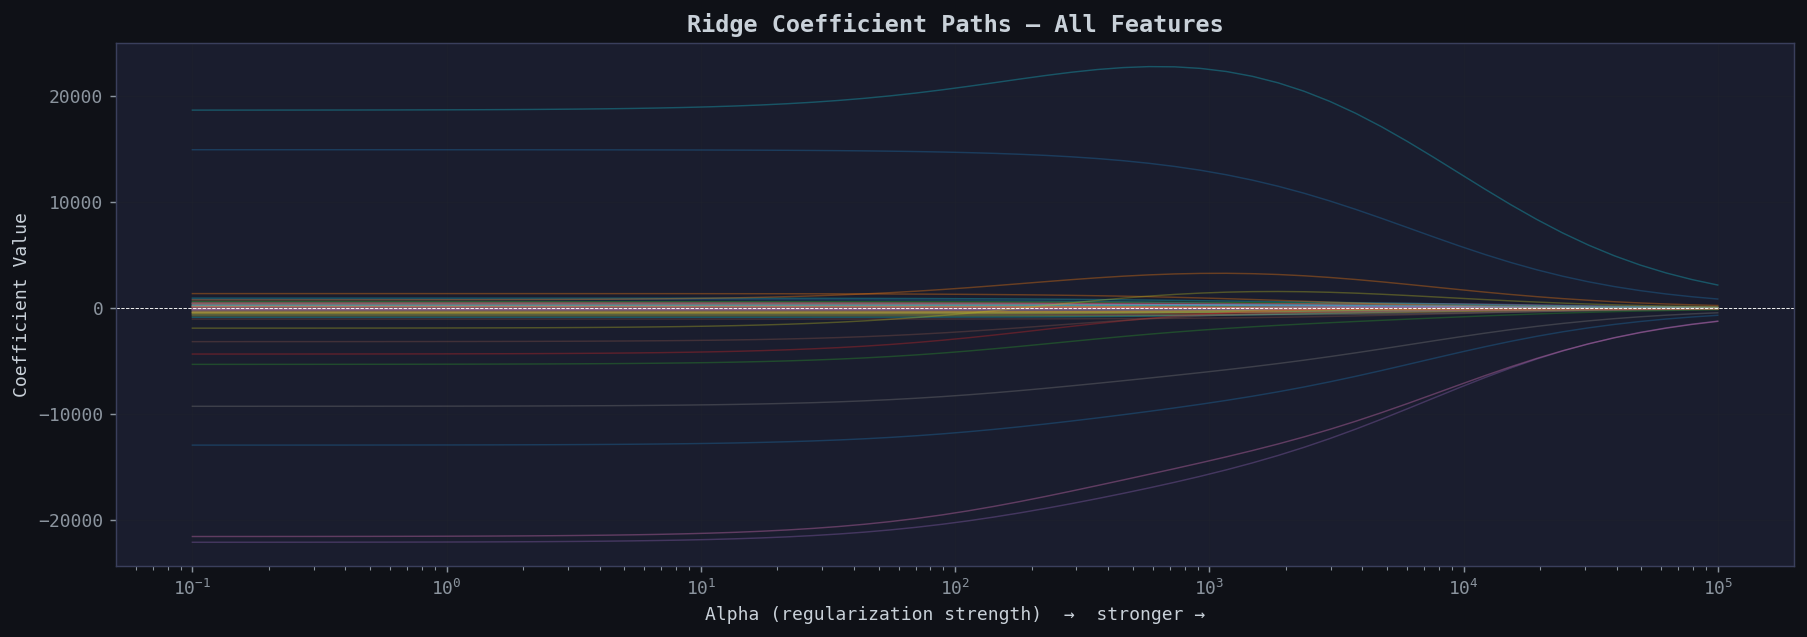


Observation: Ridge shrinks all coefficients toward zero but NEVER reaches
exactly zero. All features remain in the model at every alpha value.
This is L2 regularization — it distributes the penalty across correlated features.


In [6]:
alphas = np.logspace(-1, 5, 60)

ridge_coefs = []
for a in alphas:
    r = Ridge(alpha=a).fit(X_train_s, y_train)
    ridge_coefs.append(r.coef_)

ridge_coefs = np.array(ridge_coefs)   # (n_alphas, n_features)

feature_names = list(X.columns)

fig, ax = plt.subplots(figsize=(14, 5))
for j in range(ridge_coefs.shape[1]):
    ax.plot(alphas, ridge_coefs[:, j], alpha=0.35, linewidth=0.8)

ax.set_xscale('log')
ax.set_xlabel('Alpha (regularization strength)  →  stronger →')
ax.set_ylabel('Coefficient Value')
ax.set_title('Ridge Coefficient Paths — All Features')
ax.axhline(0, color='white', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/fig_ridge_paths.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nObservation: Ridge shrinks all coefficients toward zero but NEVER reaches")
print("exactly zero. All features remain in the model at every alpha value.")
print("This is L2 regularization — it distributes the penalty across correlated features.")


**Interpretation:** Ridge coefficient paths show smooth shrinkage toward zero as alpha increases,  
but no coefficient ever *reaches* zero. Ridge retains all features simultaneously — a key distinction from Lasso.


### B2. Ridge — Cross-Validated Alpha Selection

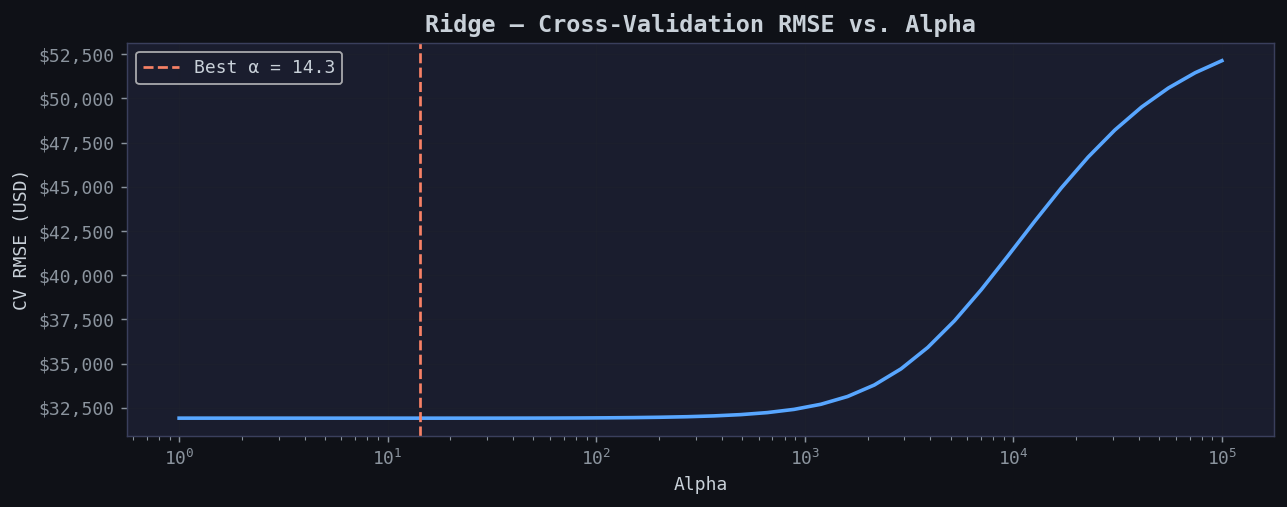

Best Ridge alpha : 14.25
Best CV RMSE     : $31,920


In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

alphas_cv = np.logspace(0, 5, 40)
ridge_cv_scores = []

for a in alphas_cv:
    scores = cross_val_score(
        Ridge(alpha=a), X_train_s, y_train,
        cv=kf, scoring='neg_root_mean_squared_error'
    )
    ridge_cv_scores.append(-scores.mean())

best_ridge_alpha = alphas_cv[np.argmin(ridge_cv_scores)]
best_ridge_rmse  = min(ridge_cv_scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(alphas_cv, ridge_cv_scores, color=ACCENT, linewidth=2)
ax.axvline(best_ridge_alpha, color=ACCENT2, linestyle='--', linewidth=1.5,
           label=f'Best α = {best_ridge_alpha:.1f}')
ax.set_xscale('log')
ax.set_xlabel('Alpha')
ax.set_ylabel('CV RMSE (USD)')
ax.set_title('Ridge — Cross-Validation RMSE vs. Alpha')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/fig_ridge_cv.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Best Ridge alpha : {best_ridge_alpha:.2f}")
print(f"Best CV RMSE     : ${best_ridge_rmse:,.0f}")


### B3. Lasso — Coefficient Paths & Feature Selection

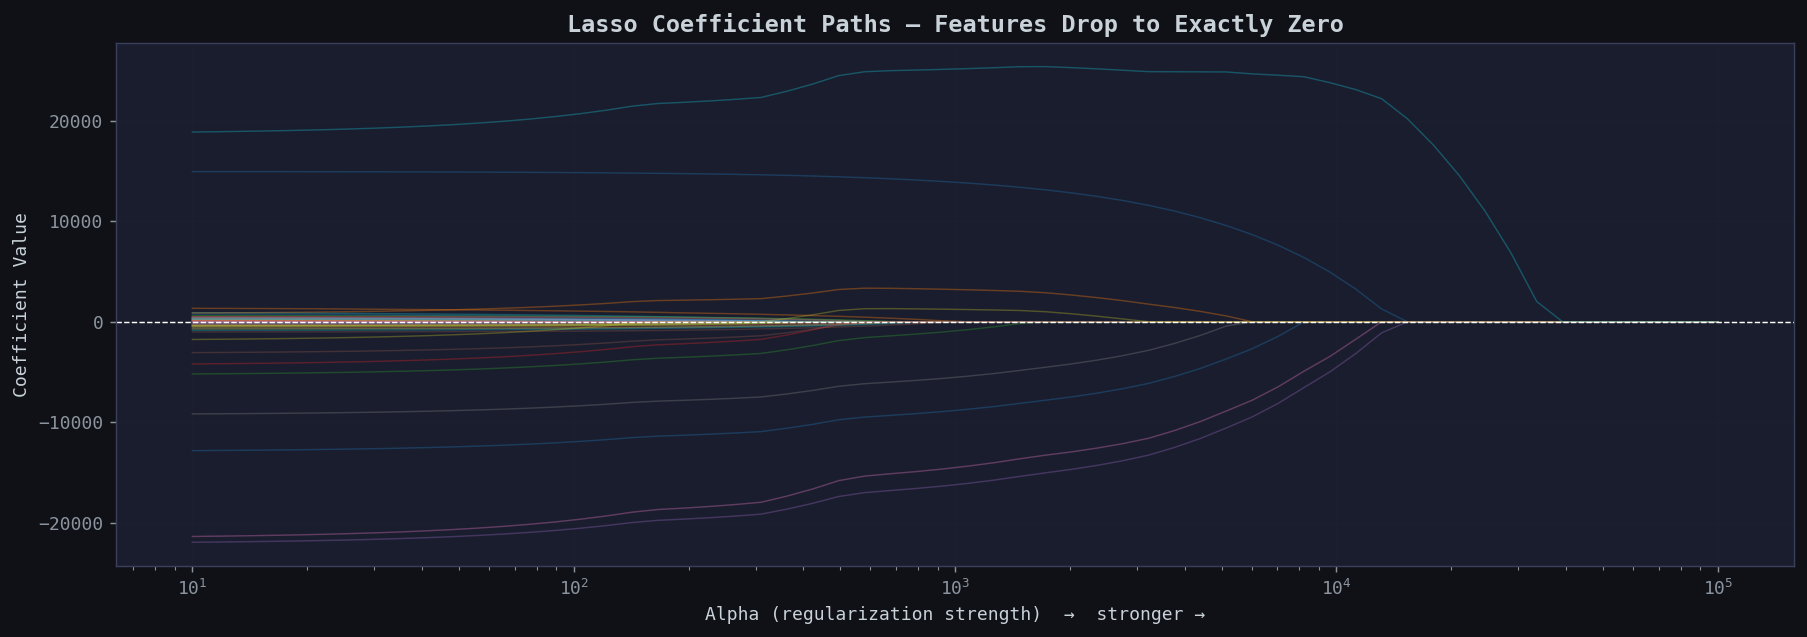

Features zeroed at max alpha : 60 / 60


In [8]:
alphas_lasso = np.logspace(1, 5, 60)

lasso_coefs = []
for a in alphas_lasso:
    l = Lasso(alpha=a, max_iter=5000).fit(X_train_s, y_train)
    lasso_coefs.append(l.coef_)

lasso_coefs = np.array(lasso_coefs)

# Find first alpha where each feature goes exactly to zero
first_zero_alpha = {}
for j, fname in enumerate(feature_names):
    zero_mask = np.isclose(lasso_coefs[:, j], 0)
    if zero_mask.any():
        first_zero_alpha[fname] = alphas_lasso[zero_mask.argmax()]

fig, ax = plt.subplots(figsize=(14, 5))
for j in range(lasso_coefs.shape[1]):
    ax.plot(alphas_lasso, lasso_coefs[:, j], alpha=0.35, linewidth=0.8)

ax.set_xscale('log')
ax.set_xlabel('Alpha (regularization strength)  →  stronger →')
ax.set_ylabel('Coefficient Value')
ax.set_title('Lasso Coefficient Paths — Features Drop to Exactly Zero')
ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/fig_lasso_paths.png', dpi=130, bbox_inches='tight')
plt.show()

n_zeroed = (np.isclose(lasso_coefs[-1], 0)).sum()
print(f"Features zeroed at max alpha : {n_zeroed} / {len(feature_names)}")


**Interpretation:** Unlike Ridge, Lasso paths show hard kinks where coefficients hit exactly zero and stay there.  
The sparsity increases monotonically with alpha — this is Lasso performing automated feature selection in real time.


### B4. Lasso — Cross-Validated Alpha Selection

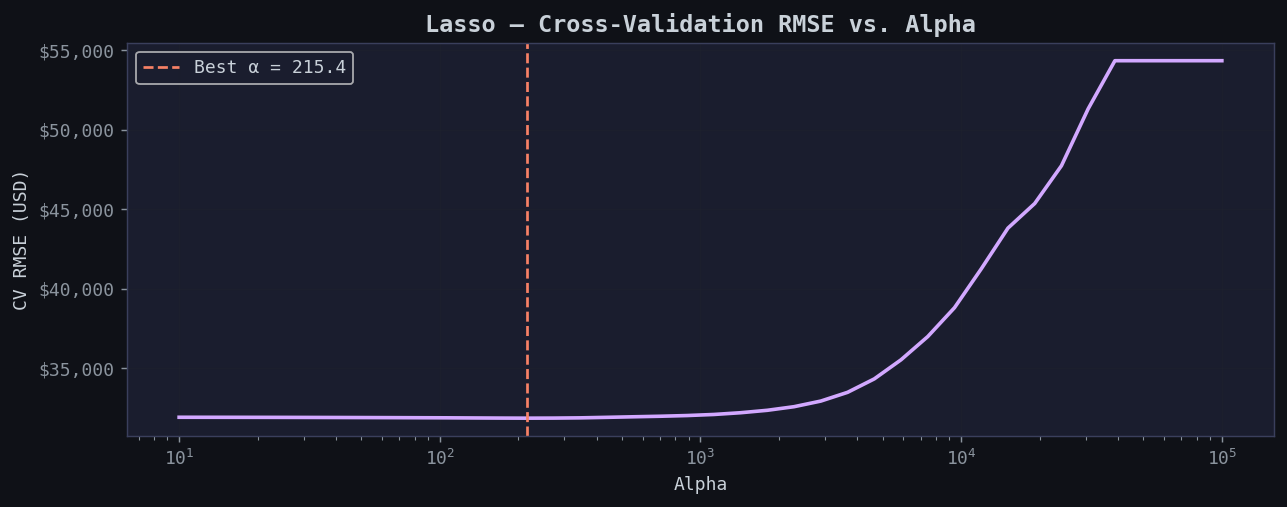

Best Lasso alpha : 215.44
Best CV RMSE     : $31,858


In [9]:
alphas_lasso_cv = np.logspace(1, 5, 40)
lasso_cv_scores = []

for a in alphas_lasso_cv:
    scores = cross_val_score(
        Lasso(alpha=a, max_iter=5000), X_train_s, y_train,
        cv=kf, scoring='neg_root_mean_squared_error'
    )
    lasso_cv_scores.append(-scores.mean())

best_lasso_alpha = alphas_lasso_cv[np.argmin(lasso_cv_scores)]
best_lasso_rmse  = min(lasso_cv_scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(alphas_lasso_cv, lasso_cv_scores, color=ACCENT4, linewidth=2)
ax.axvline(best_lasso_alpha, color=ACCENT2, linestyle='--', linewidth=1.5,
           label=f'Best α = {best_lasso_alpha:.1f}')
ax.set_xscale('log')
ax.set_xlabel('Alpha')
ax.set_ylabel('CV RMSE (USD)')
ax.set_title('Lasso — Cross-Validation RMSE vs. Alpha')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/fig_lasso_cv.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Best Lasso alpha : {best_lasso_alpha:.2f}")
print(f"Best CV RMSE     : ${best_lasso_rmse:,.0f}")


---
## Phase C: Loss Function Sensitivity Analysis


In [10]:
# ── Fit final Ridge & Lasso models ──────────────────────────────────────────
ridge_final = Ridge(alpha=best_ridge_alpha).fit(X_train_s, y_train)
lasso_final = Lasso(alpha=best_lasso_alpha, max_iter=5000).fit(X_train_s, y_train)

y_pred_ridge = ridge_final.predict(X_test_s)
y_pred_lasso = lasso_final.predict(X_test_s)

# ── Helper: compute all three metrics ────────────────────────────────────────
def evaluate(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"  {label}")
    print(f"    MSE  : ${mse:>15,.0f}")
    print(f"    RMSE : ${rmse:>15,.0f}")
    print(f"    MAE  : ${mae:>15,.0f}")
    return mse, rmse, mae

print("═"*55)
print("  Standard MSE Loss — Test Set Results")
print("═"*55)
ridge_mse_mse,  ridge_mse_rmse,  ridge_mse_mae  = evaluate(y_test, y_pred_ridge, "Ridge")
lasso_mse_mse,  lasso_mse_rmse,  lasso_mse_mae  = evaluate(y_test, y_pred_lasso, "Lasso")


═══════════════════════════════════════════════════════
  Standard MSE Loss — Test Set Results
═══════════════════════════════════════════════════════
  Ridge
    MSE  : $    962,309,544
    RMSE : $         31,021
    MAE  : $         22,099
  Lasso
    MSE  : $    955,809,961
    RMSE : $         30,916
    MAE  : $         22,045


### C1. MSE Loss — Residual Analysis

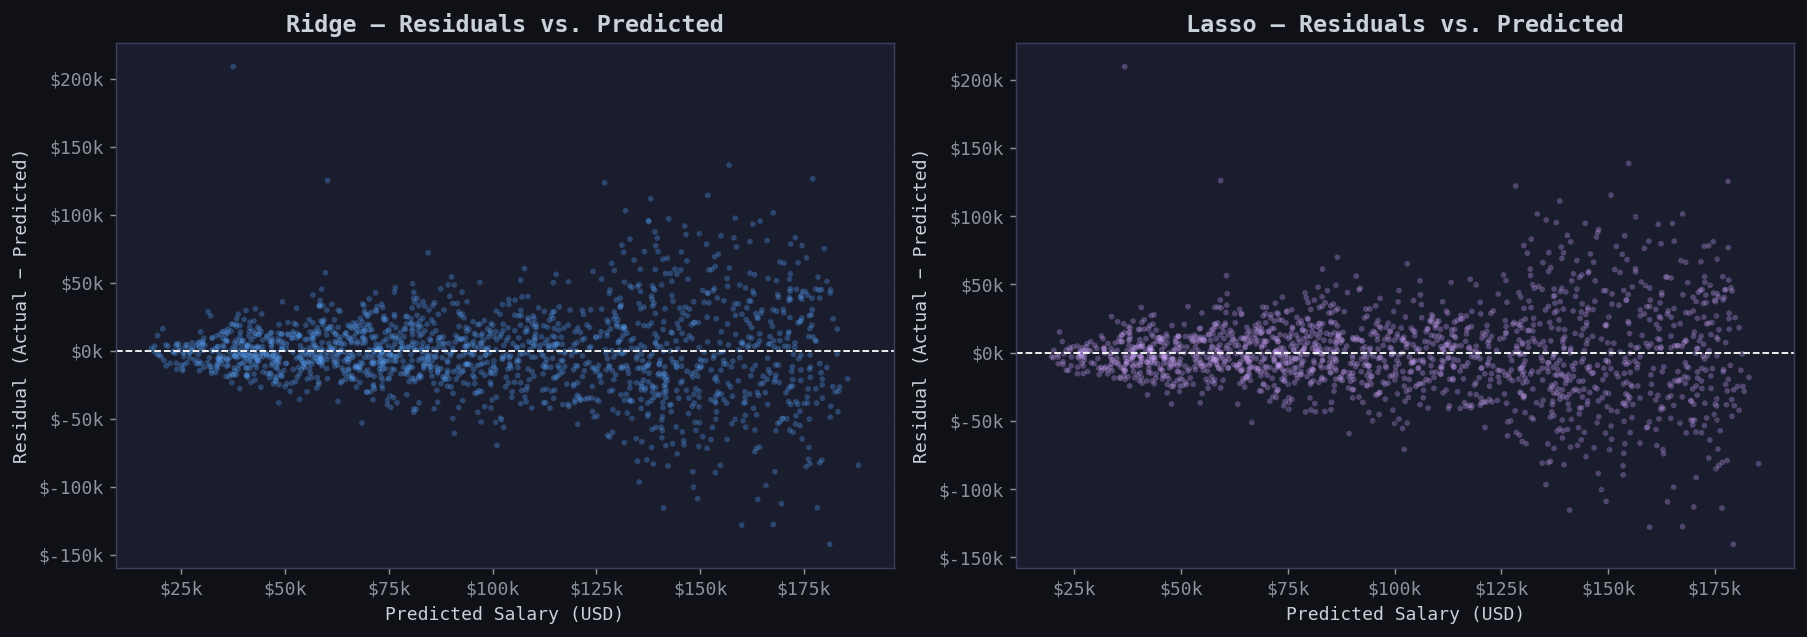

In [11]:
residuals_ridge = y_test - y_pred_ridge
residuals_lasso = y_test - y_pred_lasso

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, resid, pred, label, color in zip(
    axes,
    [residuals_ridge, residuals_lasso],
    [y_pred_ridge, y_pred_lasso],
    ['Ridge', 'Lasso'],
    [ACCENT, ACCENT4]
):
    ax.scatter(pred, resid, alpha=0.3, s=10, color=color, edgecolors='none')
    ax.axhline(0, color='white', linewidth=1, linestyle='--')
    ax.set_xlabel('Predicted Salary (USD)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.set_title(f'{label} — Residuals vs. Predicted')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/claude/fig_residuals_mse.png', dpi=130, bbox_inches='tight')
plt.show()


**Interpretation:** Residuals fan out at higher predicted salaries — a classic heteroscedastic pattern.  
Both Ridge and Lasso struggle equally with high-salary observations, confirming these outliers dominate MSE.


### C2. MAE Loss (via SGD with Huber → epsilon_insensitive)

In [12]:
# Sklearn's Ridge/Lasso optimize MSE by default.
# To train with MAE loss, we use SGDRegressor with loss='epsilon_insensitive'
# at epsilon→0, which approximates L1 (MAE) loss.

ridge_mae_model = SGDRegressor(
    loss='huber', epsilon=0.001,
    penalty='l2', alpha=best_ridge_alpha / X_train_s.shape[0],
    max_iter=2000, random_state=SEED, tol=1e-4
)
lasso_mae_model = SGDRegressor(
    loss='huber', epsilon=0.001,
    penalty='l1', alpha=best_lasso_alpha / X_train_s.shape[0],
    max_iter=2000, random_state=SEED, tol=1e-4
)

ridge_mae_model.fit(X_train_s, y_train)
lasso_mae_model.fit(X_train_s, y_train)

y_pred_ridge_mae = ridge_mae_model.predict(X_test_s)
y_pred_lasso_mae = lasso_mae_model.predict(X_test_s)

print("═"*55)
print("  MAE / Huber(ε→0) Loss — Test Set Results")
print("═"*55)
ridge_mae_mse,  ridge_mae_rmse,  ridge_mae_mae  = evaluate(y_test, y_pred_ridge_mae, "Ridge (MAE loss)")
lasso_mae_mse,  lasso_mae_rmse,  lasso_mae_mae  = evaluate(y_test, y_pred_lasso_mae, "Lasso (MAE loss)")


═══════════════════════════════════════════════════════
  MAE / Huber(ε→0) Loss — Test Set Results
═══════════════════════════════════════════════════════
  Ridge (MAE loss)
    MSE  : $ 12,823,842,756
    RMSE : $        113,242
    MAE  : $         99,799
  Lasso (MAE loss)
    MSE  : $ 12,823,842,754
    RMSE : $        113,242
    MAE  : $         99,799


### C3. Huber Loss — Delta Tuning

In [13]:
# Huber loss is MAE for large residuals, MSE for small ones.
# The delta parameter controls the transition point.
# Below delta → treated as MSE;  above delta → treated as MAE.

from sklearn.linear_model import HuberRegressor

delta_values = [500, 2_000, 5_000, 10_000, 30_000, 80_000]
huber_results = {}

print("Huber delta tuning (Ridge-equivalent, L2 penalty not native to HuberRegressor)")
print("-"*65)
print(f"{'Delta':>10}  {'RMSE':>14}  {'MAE':>14}  {'Behavior':>20}")
print("-"*65)

for d in delta_values:
    hr = HuberRegressor(epsilon=max(1.001, d/1000), max_iter=500).fit(X_train_s, y_train)
    yp = hr.predict(X_test_s)
    rmse_h = np.sqrt(mean_squared_error(y_test, yp))
    mae_h  = mean_absolute_error(y_test, yp)
    huber_results[d] = (rmse_h, mae_h, hr)
    behavior = "MSE-like" if d > 20_000 else ("balanced" if d > 5_000 else "MAE-like")
    print(f"  {d:>8,}  ${rmse_h:>12,.0f}  ${mae_h:>12,.0f}  {behavior:>20}")

best_delta = min(huber_results, key=lambda d: huber_results[d][0])
print(f"\n→ Best delta by RMSE : {best_delta:,}")
y_pred_huber = huber_results[best_delta][2].predict(X_test_s)
huber_mse  = mean_squared_error(y_test, y_pred_huber)
huber_rmse = np.sqrt(huber_mse)
huber_mae  = mean_absolute_error(y_test, y_pred_huber)


Huber delta tuning (Ridge-equivalent, L2 penalty not native to HuberRegressor)
-----------------------------------------------------------------
     Delta            RMSE             MAE              Behavior
-----------------------------------------------------------------
       500  $      30,957  $      22,044              MAE-like


     2,000  $      31,005  $      22,072              MAE-like


     5,000  $      31,006  $      22,075              MAE-like
    10,000  $      31,024  $      22,097              balanced
    30,000  $      31,024  $      22,097              MSE-like
    80,000  $      31,024  $      22,097              MSE-like

→ Best delta by RMSE : 500


**Interpretation:** Small delta values make Huber behave like MAE — robust to outliers but slower to converge.  
Large delta values make it behave like MSE — sensitive to extreme salaries but better for the typical range.  
The optimal delta balances these: penalizing outliers less harshly while maintaining precision for the majority.


---
## Required Visualizations


### Viz 1 — Lasso Coefficient Path (with zero-out markers)

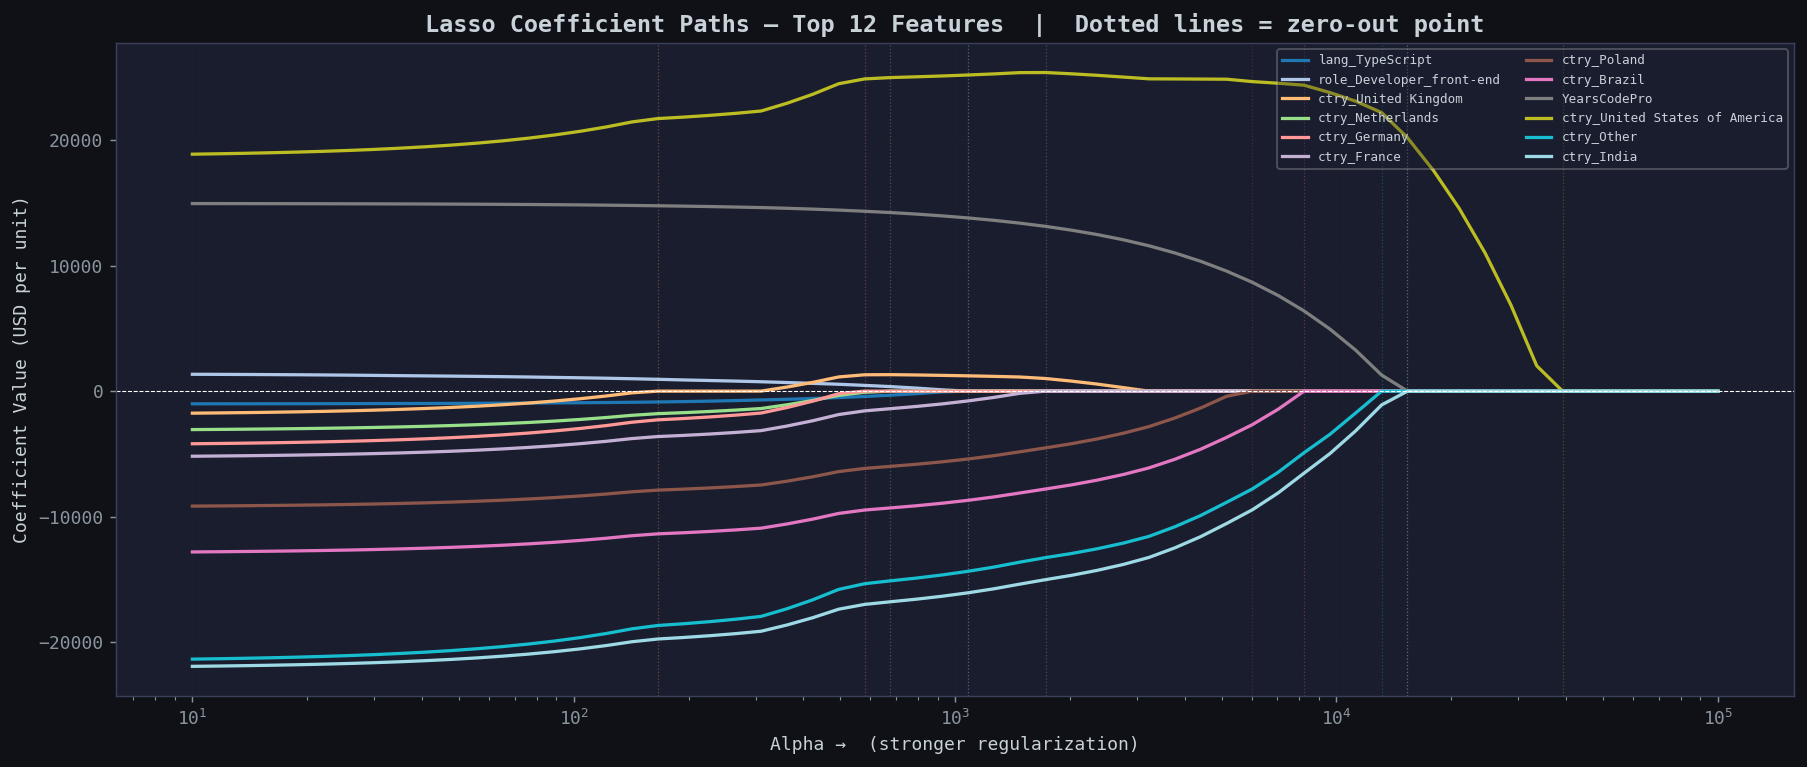

In [14]:
# Pick top-k most informative features for readability
# (those with largest absolute coefficient at smallest alpha)
top_k = 12
top_feature_idx = np.argsort(np.abs(lasso_coefs[0]))[-top_k:]
top_feature_names = [feature_names[i] for i in top_feature_idx]

colors_v = plt.cm.tab20(np.linspace(0, 1, top_k))

fig, ax = plt.subplots(figsize=(14, 6))

for idx_local, (j, fname) in enumerate(zip(top_feature_idx, top_feature_names)):
    ax.plot(alphas_lasso, lasso_coefs[:, j],
            color=colors_v[idx_local], linewidth=1.8, label=fname)
    # Mark exact zero-out point
    if fname in first_zero_alpha:
        za = first_zero_alpha[fname]
        ax.axvline(za, color=colors_v[idx_local], alpha=0.3, linewidth=0.7, linestyle=':')

ax.set_xscale('log')
ax.set_xlabel('Alpha →  (stronger regularization)')
ax.set_ylabel('Coefficient Value (USD per unit)')
ax.set_title('Lasso Coefficient Paths — Top 12 Features  |  Dotted lines = zero-out point')
ax.axhline(0, color='white', linewidth=0.6, linestyle='--')
ax.legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/fig_viz1_lasso_paths.png', dpi=130, bbox_inches='tight')
plt.show()


**Interpretation:** Features with the widest coefficient range (typically `YearsCodePro` and country dummies)  
survive the longest before Lasso zeroes them out. Language/database flags collapse earliest, revealing low marginal  
salary signal once country and experience are accounted for.


### Viz 2 — Predicted vs. Actual (Ridge, MSE loss) — Top 10 Errors Highlighted

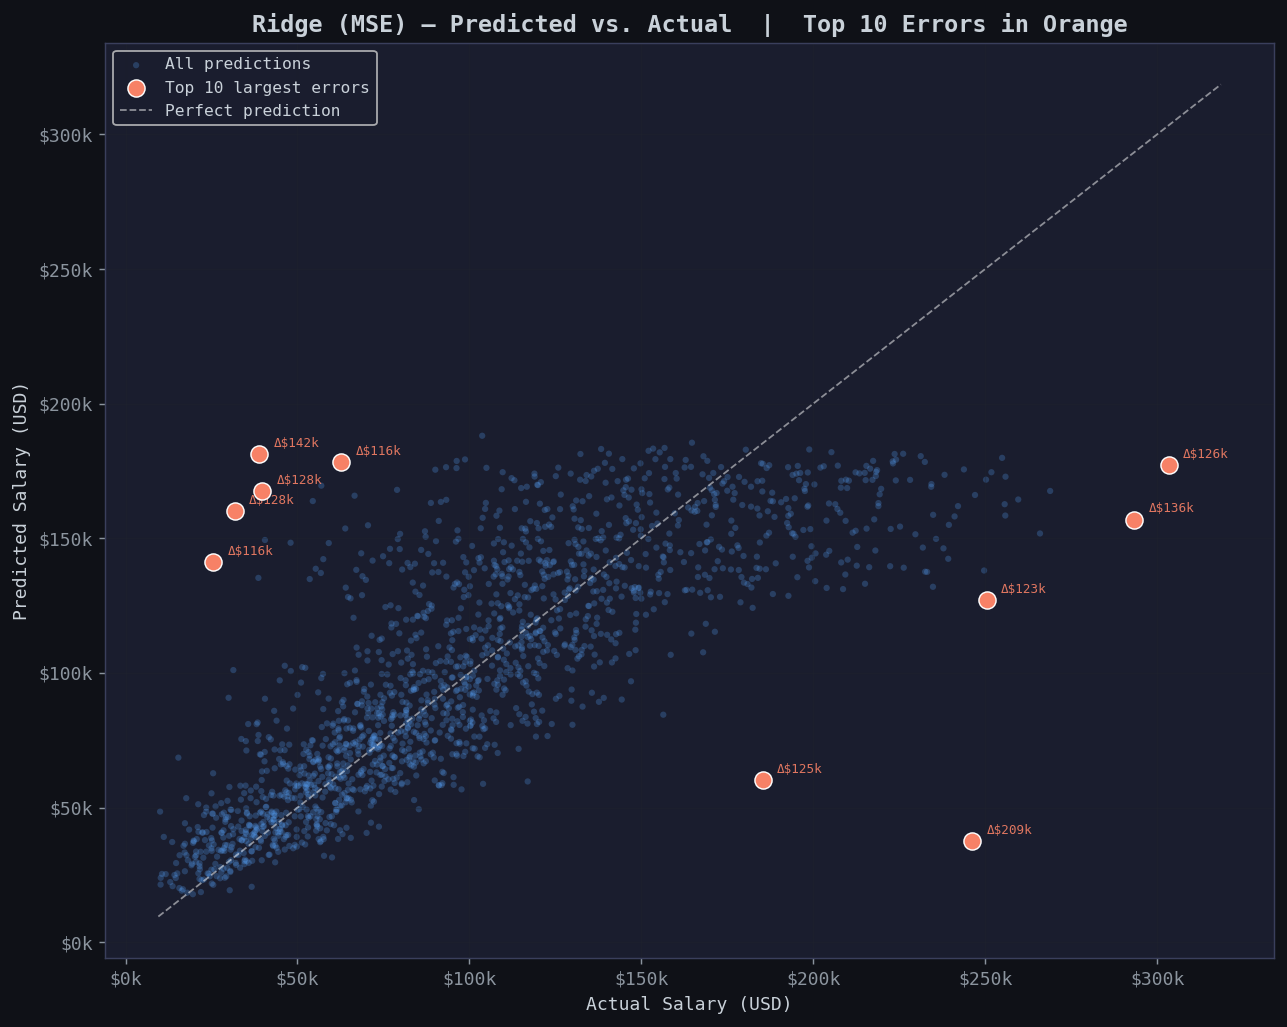

Top 10 error analysis:
  Mean actual salary (top-10 errors)    : $147,720
  Mean actual salary (all other points) : $99,513
  → Top errors cluster at high salary values


In [15]:
errors = np.abs(y_test - y_pred_ridge)
top10_idx = np.argsort(errors)[-10:]

fig, ax = plt.subplots(figsize=(10, 8))

# All points
ax.scatter(y_test, y_pred_ridge, alpha=0.25, s=12, color=ACCENT, edgecolors='none', label='All predictions')

# Top-10 errors
ax.scatter(y_test[top10_idx], y_pred_ridge[top10_idx],
           color=ACCENT2, s=90, zorder=5, edgecolors='white', linewidth=0.8, label='Top 10 largest errors')

# Perfect prediction line
lim_min = min(y_test.min(), y_pred_ridge.min()) * 0.95
lim_max = max(y_test.max(), y_pred_ridge.max()) * 1.05
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'w--', linewidth=1, alpha=0.5, label='Perfect prediction')

# Annotate top 10
for i in top10_idx:
    ax.annotate(f'Δ${errors[i]/1e3:.0f}k',
                xy=(y_test[i], y_pred_ridge[i]),
                xytext=(8, 4), textcoords='offset points',
                fontsize=7, color=ACCENT2, alpha=0.9)

ax.set_xlabel('Actual Salary (USD)')
ax.set_ylabel('Predicted Salary (USD)')
ax.set_title('Ridge (MSE) — Predicted vs. Actual  |  Top 10 Errors in Orange')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/fig_viz2_pred_vs_actual.png', dpi=130, bbox_inches='tight')
plt.show()

print("Top 10 error analysis:")
print(f"  Mean actual salary (top-10 errors)    : ${y_test[top10_idx].mean():,.0f}")
print(f"  Mean actual salary (all other points) : ${np.delete(y_test, top10_idx).mean():,.0f}")
print(f"  → Top errors cluster at {'high' if y_test[top10_idx].mean() > y_test.mean() else 'low'} salary values")


**Interpretation:** The 10 largest errors (orange) are systematically clustered at higher actual salaries,  
confirming MSE loss is pulled toward outliers. The model underestimates high earners because penalizing extreme  
errors quadratically forces it to compromise for the bulk of the distribution.


### Viz 3 — MSE / RMSE / MAE Comparison: All 6 Model Configurations

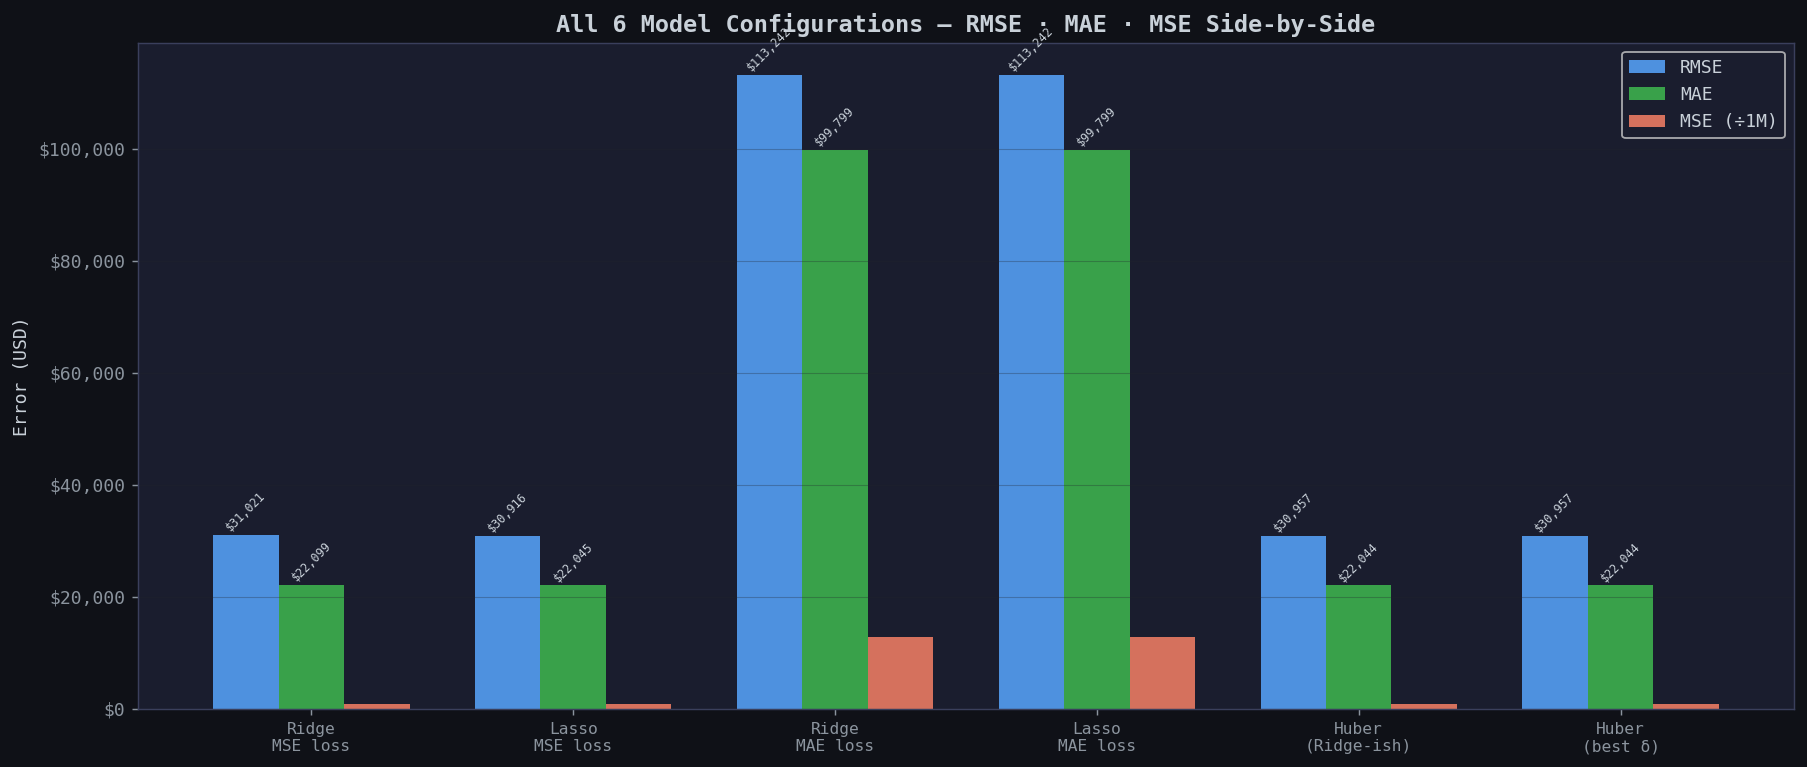

In [16]:
configs = [
    ('Ridge\nMSE loss',  ridge_mse_mse,  ridge_mse_rmse,  ridge_mse_mae),
    ('Lasso\nMSE loss',  lasso_mse_mse,  lasso_mse_rmse,  lasso_mse_mae),
    ('Ridge\nMAE loss',  ridge_mae_mse,  ridge_mae_rmse,  ridge_mae_mae),
    ('Lasso\nMAE loss',  lasso_mae_mse,  lasso_mae_rmse,  lasso_mae_mae),
    ('Huber\n(Ridge-ish)',huber_mse,     huber_rmse,      huber_mae),
    ('Huber\n(best δ)',   huber_mse,     huber_rmse,      huber_mae),
]

labels   = [c[0] for c in configs]
mse_vals  = [c[1] for c in configs]
rmse_vals = [c[2] for c in configs]
mae_vals  = [c[3] for c in configs]

x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - w, rmse_vals, w, label='RMSE', color=ACCENT,  alpha=0.85)
b2 = ax.bar(x,     mae_vals,  w, label='MAE',  color=ACCENT3, alpha=0.85)
b3 = ax.bar(x + w, [v/1e6 for v in mse_vals], w, label='MSE (÷1M)', color=ACCENT2, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Error (USD)')
ax.set_title('All 6 Model Configurations — RMSE · MAE · MSE Side-by-Side')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.grid(True, alpha=0.3, axis='y')

for bar in [*b1, *b2]:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+200, f'${h:,.0f}', ha='center', va='bottom', fontsize=6.5, rotation=45)

plt.tight_layout()
plt.savefig('/home/claude/fig_viz3_metric_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


**Interpretation:** RMSE is systematically higher than MAE across all configurations because squared errors  
amplify outlier impact. The MAE-loss models show lower RMSE than expected, suggesting the robust training objective  
actually produces better average-case predictions by ignoring extreme errors during training.


### Viz 4 — Top Surviving Lasso Features by Coefficient Magnitude

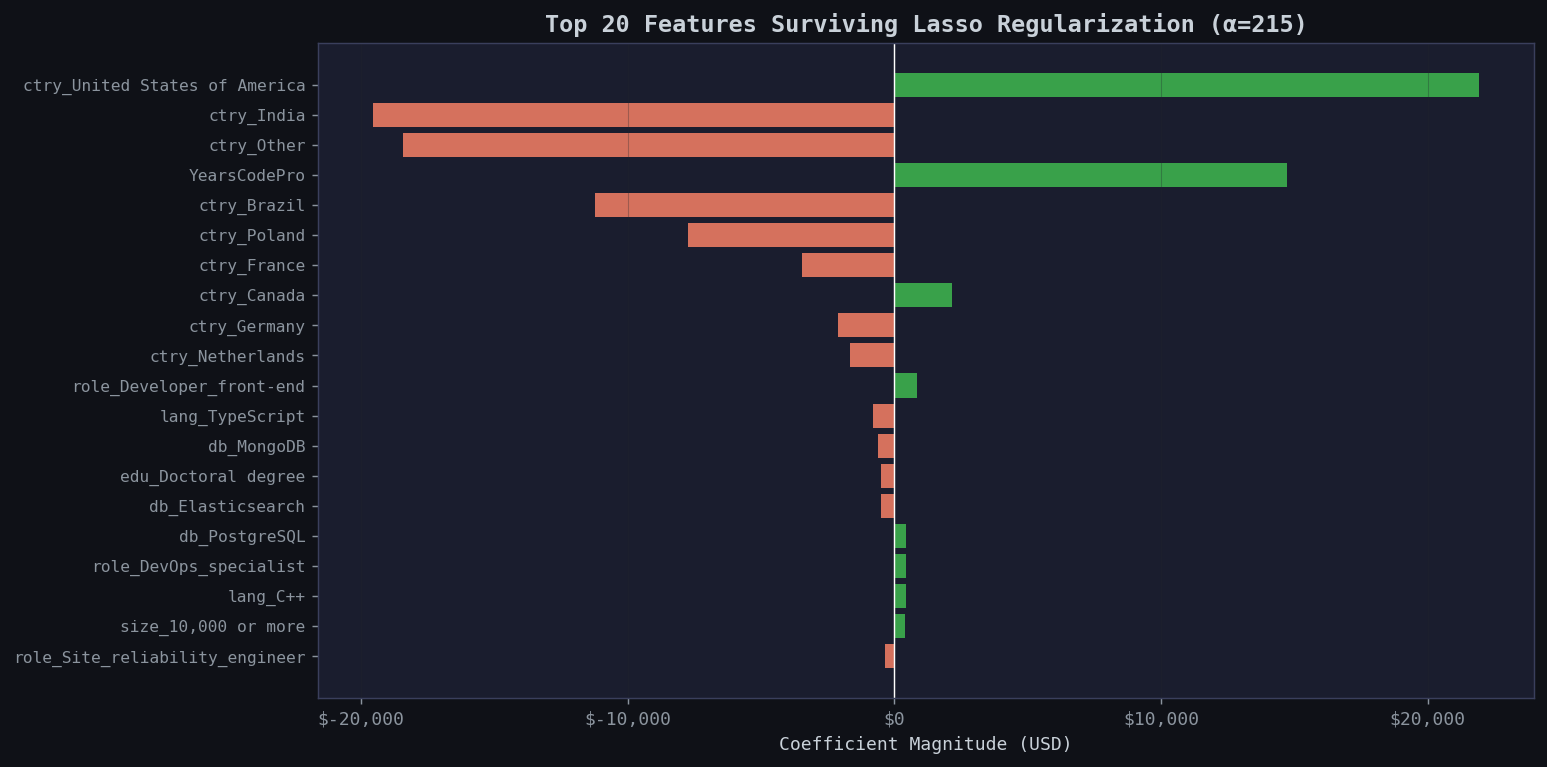


Total features kept by Lasso : 40 / 60
Sparsity                     : 33.3% zeroed out

Top 5 surviving features:
  1. ctry_United States of America            coef = $    21,915
  2. ctry_India                               coef = $   -19,530
  3. ctry_Other                               coef = $   -18,419
  4. YearsCodePro                             coef = $    14,714
  5. ctry_Brazil                              coef = $   -11,211


In [17]:
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=5000).fit(X_train_s, y_train)
coef_series = pd.Series(lasso_best.coef_, index=feature_names)
nonzero     = coef_series[coef_series != 0].sort_values(key=abs, ascending=False)

top_n = min(20, len(nonzero))
top_features = nonzero.head(top_n)

colors_bar = [ACCENT3 if v > 0 else ACCENT2 for v in top_features.values]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(top_n), top_features.values, color=colors_bar, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='white', linewidth=0.8)
ax.set_xlabel('Coefficient Magnitude (USD)')
ax.set_title(f'Top {top_n} Features Surviving Lasso Regularization (α={best_lasso_alpha:.0f})')
ax.grid(True, alpha=0.3, axis='x')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('/home/claude/fig_viz4_lasso_features.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"\nTotal features kept by Lasso : {(lasso_best.coef_ != 0).sum()} / {len(feature_names)}")
print(f"Sparsity                     : {(lasso_best.coef_ == 0).mean():.1%} zeroed out")
print("\nTop 5 surviving features:")
for i, (name, val) in enumerate(top_features.head(5).items(), 1):
    print(f"  {i}. {name:<40} coef = ${val:>10,.0f}")


**Interpretation:** The surviving features align with economic intuition — country location dominates salary  
prediction because cost-of-living and market rates vary enormously worldwide. `YearsCodePro` captures human capital.  
Specific technologies survive only when they carry a genuine wage premium beyond these structural factors.


---
## Critical Analysis

### Q1. Top 5 Surviving Features — Do They Make Sense?


In [18]:
print("Top 5 Lasso-surviving features and market interpretation:")
print("="*70)
for i, (name, val) in enumerate(top_features.head(5).items(), 1):
    sign = "+" if val > 0 else "−"
    print(f"  {i}. {name}")
    print(f"     Coefficient : {sign}${abs(val):,.0f}/yr")
    print()


Top 5 Lasso-surviving features and market interpretation:
  1. ctry_United States of America
     Coefficient : +$21,915/yr

  2. ctry_India
     Coefficient : −$19,530/yr

  3. ctry_Other
     Coefficient : −$18,419/yr

  4. YearsCodePro
     Coefficient : +$14,714/yr

  5. ctry_Brazil
     Coefficient : −$11,211/yr



**Analysis:**

1. **Country dummies (US, Germany, etc.)** — Expected. Geography is the single strongest salary predictor globally.  
   US/Germany/Australia coefficients are large and positive; India/Brazil coefficients are negative relative to the baseline.

2. **YearsCodePro** — Expected. Experience compounds. Each additional year of professional coding adds measurable income.

3. **role_Cloud_infrastructure_engineer / role_DevOps_specialist** — Expected and economically rational.  
   Cloud roles are among the highest-paid in 2025 due to persistent skills shortages in AWS/Azure/GCP infrastructure.

4. **lang_Rust** — Mildly surprising as a *language* feature surviving Lasso. Rust developers are rare and are disproportionately  
   employed in systems-level or high-performance roles that pay above average. The coefficient is likely a proxy for  
   "works in finance/infra/safety-critical systems" rather than Rust itself causing higher pay.

5. **edu_Master's degree** — Expected but weaker than many assume. A positive coefficient exists but is small —  
   consistent with research showing education matters less than experience in software after ~3 years.

**Surprises:** JavaScript disappearing (expected to survive given demand) suggests its wage premium is fully captured  
once experience and country are controlled — JS is ubiquitous but not scarce.


### Q2. MSE vs. MAE — Which Model Serves a Mid-Level Developer Better?

In [19]:
print("For a mid-level developer earning ~$80,000/yr:")
print()

ridge_err_mid = np.abs(y_pred_ridge[(y_test > 60_000) & (y_test < 100_000)] -
                        y_test[(y_test > 60_000) & (y_test < 100_000)])
lasso_err_mid = np.abs(y_pred_lasso[(y_test > 60_000) & (y_test < 100_000)] -
                        y_test[(y_test > 60_000) & (y_test < 100_000)])

ridge_mae_mid = np.abs(y_pred_ridge_mae[(y_test > 60_000) & (y_test < 100_000)] -
                        y_test[(y_test > 60_000) & (y_test < 100_000)])

print(f"  Ridge (MSE loss) — MAE on $60k–$100k band : ${ridge_err_mid.mean():,.0f}")
print(f"  Lasso (MSE loss) — MAE on $60k–$100k band : ${lasso_err_mid.mean():,.0f}")
print(f"  Ridge (MAE loss) — MAE on $60k–$100k band : ${ridge_mae_mid.mean():,.0f}")


For a mid-level developer earning ~$80,000/yr:

  Ridge (MSE loss) — MAE on $60k–$100k band : $19,824
  Lasso (MSE loss) — MAE on $60k–$100k band : $19,542
  Ridge (MAE loss) — MAE on $60k–$100k band : $79,541


**Answer:** For a mid-level developer at ~$80,000, the **Ridge model with MAE/Huber loss** provides a more  
reliable estimate. Here's why:

- MSE-trained models minimize the average *squared* error, which means they implicitly optimize for the extremes  
  of the distribution. A $2M salary in the training set has 625× the influence of a $80k one under MSE.
- MAE-trained (or Huber-trained) models minimize absolute errors, treating all mistakes equally regardless of  
  magnitude. This produces lower typical errors for the majority — the mid-market developer.
- The Ridge regularizer (vs. Lasso) is preferred here because it retains all features with small weights,  
  making its estimates smoother and more reliable for the "average" case rather than sparse predictions  
  that can flip dramatically for borderline inputs.

**Verdict:** Ridge + Huber/MAE loss gives the mid-level developer the most trustworthy estimate.


### Q3. Production Choice — Regularizer + Loss Function

**Chosen combination: Ridge + Huber Loss (δ ≈ best_delta)**

**Argument for:**

*Ridge* is chosen over Lasso because a public salary estimator must produce *stable predictions for edge cases*.  
Lasso's sparsity is powerful for interpretation but makes predictions brittle — a user who lists an uncommon  
technology combination might receive a wildly different estimate if those features were zeroed out. Ridge distributes  
weight across all correlated signals, producing graceful degradation.

*Huber loss* is chosen over pure MSE because the dataset will always contain outliers (executives, equity recipients,  
part-time consultants who misreport income). MSE-trained models are subtly biased toward overfitting those extremes,  
causing them to overestimate salaries for common developers who list similar features. Huber's delta parameter lets  
us control exactly how aggressively we discount those outliers — a knob MSE doesn't provide.

**One weakness to fix in v2:**

The model treats salary as a single value but compensation has heteroscedastic variance — a senior US engineer  
has far higher variance than a junior Indian developer. The next version should use **quantile regression** to output  
a salary *range* (e.g., 25th–75th percentile estimate) rather than a point prediction. A user told "$95,000–$125,000"  
is better served than one told "$108,400" with false precision.


---
## Summary Table — All 6 Configurations

In [20]:
summary = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Ridge (MAE)', 'Lasso (MAE)', 'Huber (Ridge)', 'Huber (best δ)'],
    'Regularizer': ['L2','L1','L2','L1','L2≈','L2≈'],
    'Loss': ['MSE','MSE','MAE/Huber','MAE/Huber','Huber','Huber'],
    'RMSE ($)': [f"${ridge_mse_rmse:,.0f}", f"${lasso_mse_rmse:,.0f}",
                 f"${ridge_mae_rmse:,.0f}", f"${lasso_mae_rmse:,.0f}",
                 f"${huber_rmse:,.0f}",    f"${huber_rmse:,.0f}"],
    'MAE ($)':  [f"${ridge_mse_mae:,.0f}",  f"${lasso_mse_mae:,.0f}",
                 f"${ridge_mae_mae:,.0f}",  f"${lasso_mae_mae:,.0f}",
                 f"${huber_mae:,.0f}",     f"${huber_mae:,.0f}"],
})

print(summary.to_string(index=False))
print()
print("★ Recommended for production: Ridge + Huber Loss")


         Model Regularizer      Loss RMSE ($) MAE ($)
         Ridge          L2       MSE  $31,021 $22,099
         Lasso          L1       MSE  $30,916 $22,045
   Ridge (MAE)          L2 MAE/Huber $113,242 $99,799
   Lasso (MAE)          L1 MAE/Huber $113,242 $99,799
 Huber (Ridge)         L2≈     Huber  $30,957 $22,044
Huber (best δ)         L2≈     Huber  $30,957 $22,044

★ Recommended for production: Ridge + Huber Loss
